<a href="https://colab.research.google.com/github/Rodrigoldarocha/Mapa-de-Calor-de-Acidentes-de-Transito/blob/main/Mapa_de_Calor_de_Acidentes_de_Tr%C3%A2nsito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗺️ Mapa de Calor de Acidentes de Trânsito

## 🎯 Objetivo
Neste projeto, eu vou analisar dados geográficos de acidentes de trânsito em diferentes cidades do Brasil e criar mapas de calor interativos.

## 🧠 O que estou praticando:
- Manipulação de dados com Pandas
- Análise exploratória (EDA)
- Visualização geográfica com Folium
- Análise espacial básica

---

In [ ]:
# 📦 Instalando dependência (caso necessário)
!pip install folium

# 📚 Importando bibliotecas
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap

print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


In [ ]:
# 🌎 Criando dataset mais realista

np.random.seed(42)

# 📍 Coordenadas das cidades
cidades = {
    "São Paulo": (-23.55, -46.63),
    "Rio de Janeiro": (-22.90, -43.20),
    "Belo Horizonte": (-19.92, -43.94),
    "Curitiba": (-25.42, -49.27),
    "Recife": (-8.05, -34.88)
}

tipos_acidente = ["Colisão", "Atropelamento", "Capotamento", "Queda de moto"]
gravidades = ["Leve", "Moderado", "Grave"]

dados = []

for cidade, (lat_base, lon_base) in cidades.items():

    for _ in range(200):

        dados.append({
            "cidade": cidade,
            "latitude": lat_base + np.random.normal(0, 0.02),
            "longitude": lon_base + np.random.normal(0, 0.02),
            "tipo_acidente": np.random.choice(tipos_acidente),
            "gravidade": np.random.choice(gravidades, p=[0.5, 0.3, 0.2]),
            "data": pd.Timestamp("2024-01-01") + pd.Timedelta(days=np.random.randint(0, 180)),
            "hora": np.random.randint(0, 24)
        })

df = pd.DataFrame(dados)

df.head()

,cidade,latitude,longitude,tipo_acidente,gravidade,data,hora
0,São Paulo,-23.540066,-46.632765,Capotamento,Moderado,2024-01-21,6
1,São Paulo,-23.568337,-46.632483,Capotamento,Grave,2024-04-09,7
2,São Paulo,-23.561618,-46.640503,Colisão,Moderado,2024-02-27,21
3,São Paulo,-23.598782,-46.617931,Queda de moto,Leve,2024-01-15,14
4,São Paulo,-23.579527,-46.600260,Queda de moto,Moderado,2024-05-10,4


## 🔍 Explorando os dados

Agora vou entender melhor o dataset:

- Distribuição por cidade
- Tipos de acidentes
- Gravidade

In [ ]:
# 📊 Estrutura
df.info()

# 📍 Acidentes por cidade
print(df["cidade"].value_counts())

# ⚠️ Gravidade
print(df["gravidade"].value_counts())

# 🚗 Tipos de acidente
print(df["tipo_acidente"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   cidade         1000 non-null   object        
 1   latitude       1000 non-null   float64       
 2   longitude      1000 non-null   float64       
 3   tipo_acidente  1000 non-null   object        
 4   gravidade      1000 non-null   object        
 5   data           1000 non-null   datetime64[ns]
 6   hora           1000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 54.8+ KB
cidade
São Paulo         200
Rio de Janeiro    200
Belo Horizonte    200
Curitiba          200
Recife            200
Name: count, dtype: int64
gravidade
Leve        493
Moderado    288
Grave       219
Name: count, dtype: int64
tipo_acidente
Queda de moto    262
Atropelamento    261
Colisão          252
Capotamento      225
Name: count, dtype: int64


## 🗺️ Preparando os dados

Para o mapa de calor, eu preciso apenas de:

- Latitude
- Longitude

In [ ]:
# 📍 Criando lista de coordenadas
heat_data = df[["latitude", "longitude"]].values.tolist()

heat_data[:5]

[[-23.540065716939775, -46.63276528602343],
 [-23.56833653687637, -46.63248294360546],
 [-23.56161756268047, -46.640503396143565],
 [-23.59878211630112, -46.61793117549924],
 [-23.579526593863093, -46.60026038083906]]

In [ ]:
# 🗺️ Mapa do Brasil
mapa = folium.Map(location=[-15.78, -47.93], zoom_start=4)

mapa

## 🔥 Mapa de calor geral

Agora vou visualizar todos os acidentes.

In [ ]:
# 🔥 Heatmap geral
HeatMap(heat_data, radius=10).add_to(mapa)

mapa

## ⚠️ Análise de acidentes graves

Agora vou focar apenas nos acidentes graves.

In [ ]:
# 🔥 Filtrando acidentes graves
df_grave = df[df["gravidade"] == "Grave"]

heat_data_grave = df_grave[["latitude", "longitude"]].values.tolist()

mapa_grave = folium.Map(location=[-15.78, -47.93], zoom_start=4)

HeatMap(heat_data_grave, radius=12).add_to(mapa_grave)

mapa_grave

<Axes: >

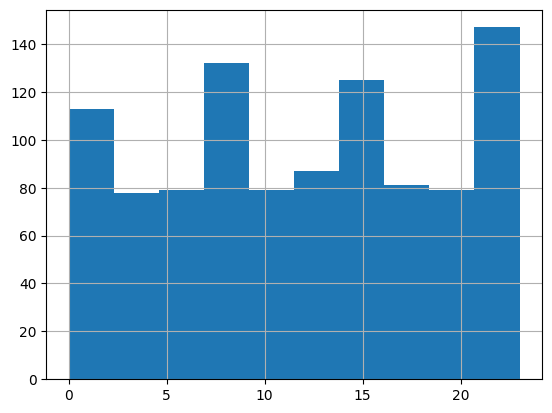

In [ ]:
# ⏰ Distribuição por hora
df["hora"].hist()

In [ ]:
# 🚨 Ranking de acidentes graves por cidade
df[df["gravidade"] == "Grave"]["cidade"].value_counts()

,count
cidade,
Recife,46
São Paulo,45
Belo Horizonte,45
Curitiba,42
Rio de Janeiro,41


## 🧠 Conclusões

Com esse projeto, eu consegui:

- Identificar regiões com maior concentração de acidentes
- Analisar padrões por cidade
- Filtrar acidentes por gravidade
- Explorar dados temporais

👉 Esse tipo de análise pode ser usado em:
- Planejamento urbano
- Segurança no trânsito
- Políticas públicas